<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div style="text-align: center; margin-bottom: 10px;">
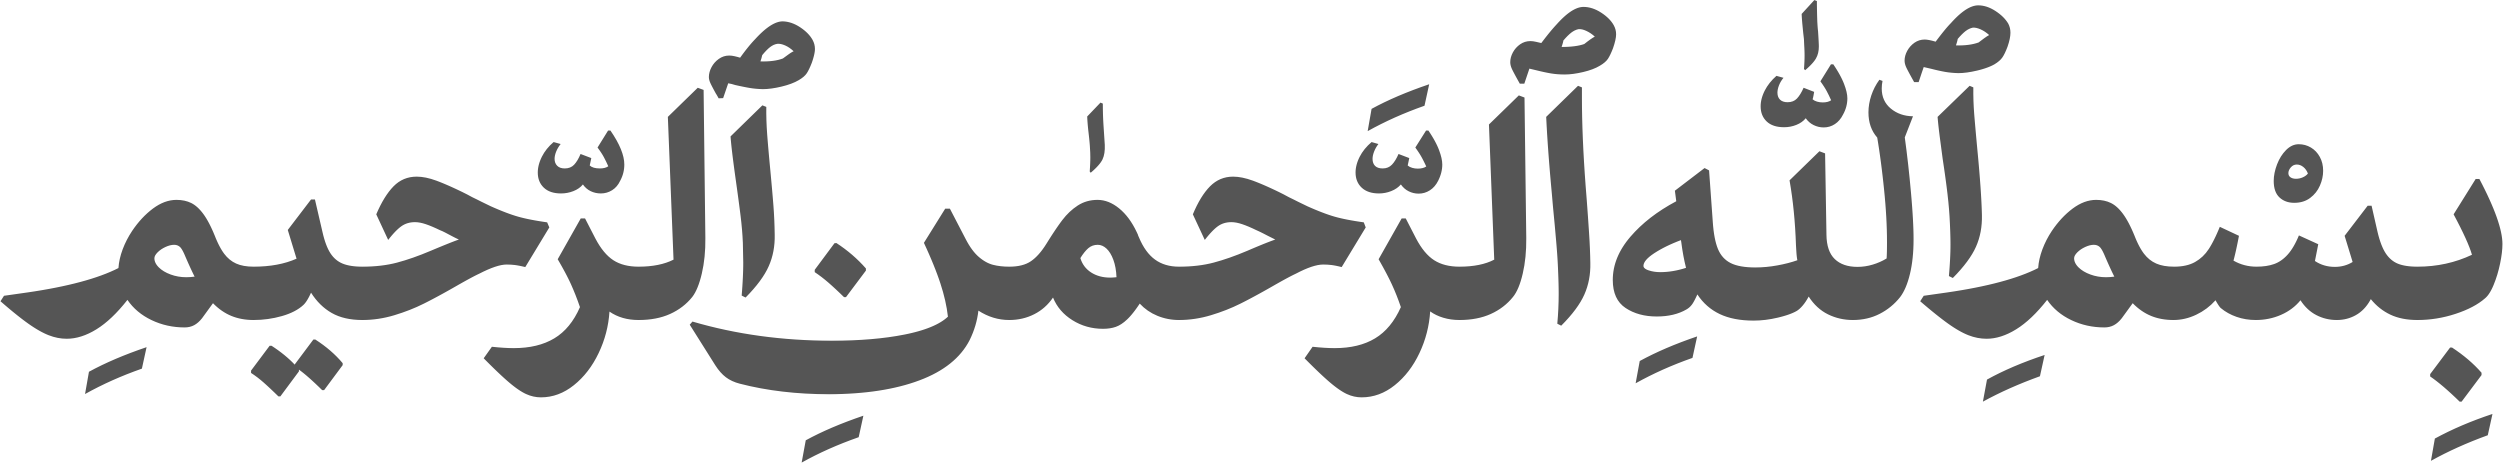
<div style="margin-top: 18px; display: flex; justify-content: center; align-items: center; gap: 30px;">
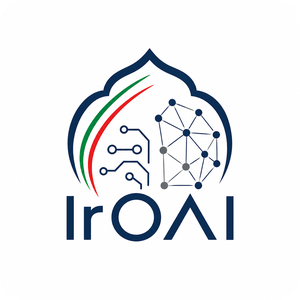
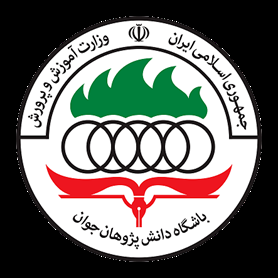
</div>
</div>
<h1 style="text-align: right;color: var(--jp-content-font-color1, #1e6bb8);">تمرین عملی المپیاد هوش مصنوعی — دوره دوم (۱۴۰۴-۱۴۰۵)</h1>
<h2 style="text-align: right;color: #3498db;">Regularization — Dropout، Batch Normalization و Data Augmentation</h2>
<p style="text-align: right;"><b>موضوع:</b> جلوگیری از بیش‌برازش (Overfitting) در شبکه‌های عصبی</p>
<p style="text-align: right;color: var(--jp-ui-font-color2, #6b7280);">این یک تمرین آموزشی است؛ هیچ نمره‌ای از سامانه داوری دریافت نمی‌کند. هدف، یادگیری و بررسی نتیجه کار خودتان است.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">مقدمه</h2>
<h3 style="text-align: right;">بیش‌برازش (Overfitting) چیست؟</h3>
<p style="text-align: right;">
یک مدل یادگیری ماشین «بیش‌برازش» می‌کند وقتی عملکرد بسیار خوبی روی داده‌های آموزش (Train) داشته باشد اما روی داده‌هایی که در آموزش ندیده
(Validation / Test) نتواند خوب عمل کند. دلیل این اتفاق معمولاً این است که مدل به‌جای یادگرفتن الگوی عمومی داده‌ها، جزئیات و نویزهای خاص داده آموزش را حفظ می‌کند.
هرچه داده آموزش <b>کوچک‌تر</b> و مدل <b>پرانعطاف‌تر</b> باشد، بیش‌برازش راحت‌تر رخ می‌دهد.
</p>
<p style="text-align: right;">
برای اندازه‌گیری این پدیده از «شکاف تعمیم» (Generalization Gap) استفاده می‌کنیم — اختلاف دقت روی داده آموزش و دقت روی داده اعتبارسنجی:
</p>
$$
\text{Gap} = \text{Accuracy}_{\text{train}} - \text{Accuracy}_{\text{val}}
$$
<p style="text-align: right;">
در این تمرین روی مجموعه داده MNIST (ارقام دست‌نویس ۲۸×۲۸ خاکستری) یک <b>MLP</b> ساده آموزش می‌دهیم. اول نشان می‌دهیم که با <b>کاهش حجم داده آموزش</b>، همین مدل ساده به‌سادگی بیش‌برازش می‌کند؛ سپس سه ابزار اصلی مقابله با آن را یکی‌یکی اضافه می‌کنیم و اثر هرکدام را روی شکاف تعمیم بررسی می‌کنیم:
</p>
<ol style="text-align: right;">
<li style="text-align: right;"><b>Dropout</b> — خاموش‌کردن تصادفی بخشی از نورون‌ها در زمان آموزش، تا شبکه به نورون‌های خاصی وابسته نشود.</li>
<li style="text-align: right;"><b>Batch Normalization</b> — نرمال‌سازی توزیع ورودی هر لایه که آموزش را پایدارتر و سریع‌تر می‌کند و به‌دلیل نویز مینی‌بچ، یک اثر منظم‌سازیِ ملایم هم دارد. این یکی را <b>از صفر</b> پیاده‌سازی می‌کنیم.</li>
<li style="text-align: right;"><b>Data Augmentation</b> — اعمال تغییرات تصادفیِ بی‌ضرر روی داده‌های آموزش (مثل جابه‌جایی و چرخش) تا شبکه نمونه‌های خاص را حفظ نکند. یک augmentation <b>سفارشی</b> هم می‌سازیم.</li>
</ol>
<p style="text-align: right;">
هرجایی که ممکن باشد از امکانات خودِ PyTorch استفاده می‌کنیم. در پایان همه مدل‌ها را با تنظیمات یکسان (همان داده، همان seed، همان تعداد دوره، همان نرخ یادگیری) مقایسه می‌کنیم و می‌بینیم هر تکنیک چقدر شکاف تعمیم را کم کرده است.
</p>
<p style="text-align: right;">
در این تمرین این فازها را پشت سر می‌گذارید: بارگذاری و اکتشاف داده، مدل پایه و مشاهده بیش‌برازش با کاهش داده، Dropout، Batch Normalization (از صفر و مقایسه با پیاده‌سازی خود PyTorch)، Augmentation (آماده + سفارشی)، در پایان ترکیب همه و یک فاز ارزیابی که نتیجه کار خود را با مقدار مرجع مقایسه می‌کنید.
</p>
<p style="text-align: right;">
<b>نکته مهم:</b> سلول Setup فقط importها و ثابت‌های آزمایش را آماده کرده است — <b>حلقه آموزش، ارزیابی و رسم نمودار را خودتان می‌نویسید</b> (در فاز ۲) و در فازهای بعد از همان توابع استفاده می‌کنید تا مقایسه‌ها منصفانه بماند.
</p>
</div>


In [1]:
import time
start_time = time.time()
print("Timer started")

Timer started


In [2]:
# Setup - read-only cell; do not edit
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.datasets import MNIST

%matplotlib inline

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = os.path.join(".", "data")
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081
MNIST_CLASSES = [str(d) for d in range(10)]
BASE_TRANSFORM = T.Compose([T.ToTensor(), T.Normalize(MNIST_MEAN, MNIST_STD)])

# experiment protocol (same for every model -> fair comparison)
TRAIN_PER_CLASS = 100          # 1000 training samples in total
VAL_PER_CLASS = 100            # 1000 validation samples
BATCH_SIZE = 128
EPOCHS = 45
LR = 1e-3


def set_seed(seed=SEED):
    """Fix all random sources so experiments are comparable."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۱ — بارگذاری داده و اکتشاف</h2>
<h3 style="text-align: right;">مجموعه داده MNIST</h3>
<p style="text-align: right;">
MNIST مجموعه‌ای از ۷۰٬۰۰۰ تصویر خاکستری ۲۸×۲۸ پیکسلی از ارقام دست‌نویس ۰ تا ۹ است (۶۰٬۰۰۰ نمونه آموزش و ۱۰٬۰۰۰ نمونه آزمون).
هر تصویر یک ورودی با ابعاد <code dir="ltr">(1, 28, 28)</code> است؛ خروجی هم یکی از ۱۰ رقم است. در این تمرین تصویر را <b>صاف (Flatten)</b> می‌کنیم و به یک <b>MLP</b> (پرسپترون چندلایه) می‌دهیم — بدون هیچ کانولوشنی.
</p>
<p style="text-align: right;">
در سلول زیر:
</p>
<ul style="text-align: right;">
<li style="text-align: right;">مجموعه آموزش و آزمون را با <code dir="ltr">torchvision.datasets.MNIST</code> بارگذاری کنید
(<b>root</b> را <code dir="ltr">DATA_ROOT</code> و <b>transform</b> را <code dir="ltr">BASE_TRANSFORM</code> بگذارید؛ داده در اولین اجرا دانلود می‌شود — حدود ۱۱ مگابایت). نام‌ها: <code dir="ltr">train_full</code> و <code dir="ltr">test_set</code>.</li>
<li style="text-align: right;">تعداد نمونه‌ها و شکل هر نمونه را چاپ کنید.</li>
<li style="text-align: right;">تعداد نمونه هر کلاس را در مجموعه آموزش بشمارید و چاپ کنید.</li>
<li style="text-align: right;">۸ نمونه تصادفی (با <code dir="ltr">random.Random(SEED)</code>) انتخاب کنید و با <code dir="ltr">matplotlib</code> نمایش دهید — تصویر را <code dir="ltr">squeeze(0)</code> کنید و با <code dir="ltr">cmap="gray"</code> رسم کنید؛ چون داده نرمال شده، برای دیدن تصویر عادی، پیکسل‌ها را با
<code dir="ltr">img * MNIST_STD + MNIST_MEAN</code> بازگردانید (و بین ۰ و ۱ برش بزنید).</li>
</ul>

</div>


train samples: 60000
test samples: 10000
image shape: (1, 28, 28)
samples per class: [5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]


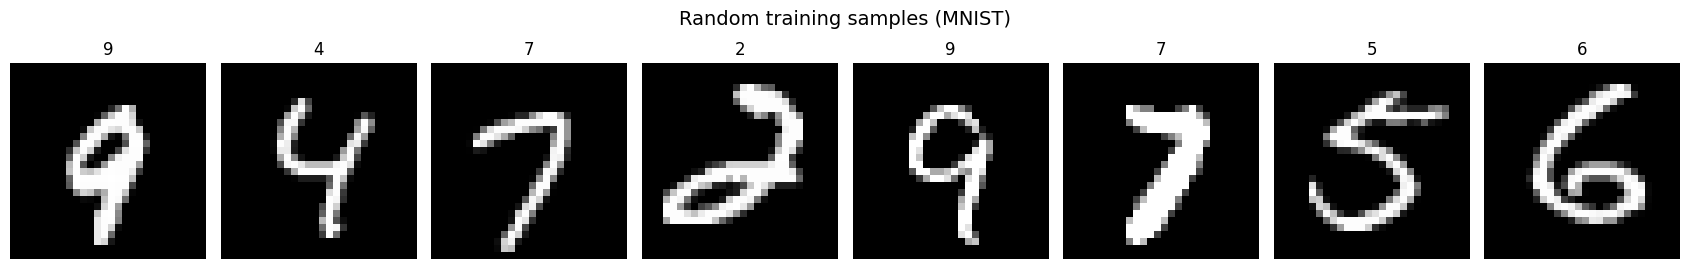

In [3]:
# TODO: Phase 1 - load MNIST and explore it
#   train_full = MNIST(root=DATA_ROOT, train=True, download=True, transform=BASE_TRANSFORM)
#   test_set   = MNIST(root=DATA_ROOT, train=False, download=True, transform=BASE_TRANSFORM)
# TODO: print dataset sizes and the image shape of one sample
# TODO: count and print samples per class (0..9)
# TODO: pick 8 samples with random.Random(SEED) and plot them
#       (imshow with cmap="gray"; squeeze the (1,28,28) tensor; denormalize first)

train_full = MNIST(root=DATA_ROOT, train=True, download=True,
                   transform=BASE_TRANSFORM)
test_set = MNIST(root=DATA_ROOT, train=False, download=True,
                 transform=BASE_TRANSFORM)
print("train samples:", len(train_full))
print("test samples:", len(test_set))
print("image shape:", tuple(train_full[0][0].shape))

counts = {}
for _, y in train_full:
    counts[y] = counts.get(y, 0) + 1
print("samples per class:", [counts[c] for c in range(10)])

rng = random.Random(SEED)
ids = rng.sample(range(len(train_full)), 8)
fig, axes = plt.subplots(1, 8, figsize=(17, 2.8))
for ax, i in zip(axes, ids):
    img, y = train_full[i]
    img = np.clip(img.squeeze(0).numpy() * MNIST_STD + MNIST_MEAN, 0.0, 1.0)
    ax.imshow(img, cmap="gray")
    ax.set_title(str(y), fontsize=12)
    ax.axis("off")
plt.suptitle("Random training samples (MNIST)", fontsize=14)
plt.tight_layout()
plt.show()


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;">
<li style="text-align: right;">در توزیع کلاس‌ها چه می‌بینید؟ آیا مجموعه داده متوازن (Balanced) است؟</li>
<li style="text-align: right;">فقط ۲۸×۲۸ پیکسل خاکستری چقدر اطلاعات درباره یک رقم دارد؟ کدام ارقام از نظر ظاهری شبیه‌ترین‌اند؟</li>
<li style="text-align: right;">چرا قبل از دادن تصویر به شبکه، آن را با میانگین و انحراف‌معیار (Normalize) می‌کنیم؟</li>
</ul>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;">
<b>پاسخ:</b> مجموعه داده تقریباً متوازن است؛ هر کلاس بین حدود ۵۴۰۰ تا ۶۷۰۰ نمونه دارد (مثلاً کلاس ۱ با ۶۷۴۲ نمونه بیشترین و کلاس ۵ با ۵۴۲۱ نمونه کمترین تعداد را دارد). این اختلاف جزئی معمولاً تأثیر چندانی روی آموزش ندارد ولی خوب است بدانیم داده «تقریباً» متوازن است.
</p>
<p style="text-align: right;">
هر تصویر فقط ۷۸۴ عدد خاکستری است؛ شبکه باید ویژگی‌های ظریف و مفید (مثل انحناها و ضخامت خطوط) را از همین پیکسل‌ها یاد بگیرد. ارقامی مثل ۳ و ۸ یا ۴ و ۹ از نظر شکل بسیار شبیه‌اند، پس خطاهای بین این جفت‌ها طبیعی‌ترین خطاهای مدل هستند.
</p>
<p style="text-align: right;">
Normalize مقیاس همه ویژگی‌ها (پیکسل‌ها) را یکسان می‌کند (میانگین ۰ و انحراف معیار ۱). بدون آن، مقیاس‌های متفاوت ورودی باعث می‌شود بهینه‌ساز در برخی جهت‌ها گام‌های خیلی بزرگ و در برخی خیلی کوچک بردارد؛ نرمال‌سازی همگرایی را پایدارتر و سریع‌تر می‌کند.
</p>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۲ — مدل پایه بدون Regularization: با کاهش داده، بیش‌برازش را ببینید</h2>
<p style="text-align: right;">
اول یک MLP ساده می‌سازیم — <b>بدون</b> هیچ Dropout یا BatchNorm — با این ساختار:
</p>
<ul style="text-align: right;">
<li style="text-align: right;"><code dir="ltr">Flatten</code> (هر تصویر ۲۸×۲۸ → بردار ۷۸۴تایی)</li>
<li style="text-align: right;"><code dir="ltr">Linear(784 → 256)</code> + <code dir="ltr">ReLU</code></li>
<li style="text-align: right;"><code dir="ltr">Linear(256 → 128)</code> + <code dir="ltr">ReLU</code></li>
<li style="text-align: right;"><code dir="ltr">Linear(128 → 10)</code></li>
</ul>
<p style="text-align: right;">
توجه کنید که این مدل برای MNIST خیلی بزرگ و پرانعطاف است — تعداد پارامترهایش (~۲۵۰ هزار) از تعداد نمونه‌های آموزشی که در اختیارش می‌گذاریم خیلی بیشتر است؛ شرط لازمِ یک بیش‌برازش تماشایی.
</p>
<p style="text-align: right;">
در این فاز علاوه بر مدل، <b>دو تابع را هم خودتان می‌نویسید</b> که در همه فازهای بعد از آن‌ها استفاده می‌کنید:
</p>
<ul style="text-align: right;">
<li style="text-align: right;"><code dir="ltr">evaluate(model, loader) -> (accuracy, mean_loss)</code> — با <code dir="ltr">model.eval()</code> و <code dir="ltr">torch.no_grad()</code>.</li>
<li style="text-align: right;"><code dir="ltr">train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, seed=SEED) -> history</code> —
حلقه آموزش با <code dir="ltr">Adam</code> و <code dir="ltr">CrossEntropyLoss</code>: در هر دوره اول با <code dir="ltr">model.train()</code> روی مینی‌بچ‌ها گام بردارید و دقت آموزش را بگیرید، سپس با <code dir="ltr">evaluate</code> دقت اعتبارسنجی را حساب کنید. خروجی: دیکشنری با لیست‌های <code dir="ltr">"train_acc"</code> و <code dir="ltr">"val_acc"</code> (یک بار در ابتدای هر اجرا <code dir="ltr">set_seed(seed)</code> را صدا بزنید تا همه اجراها قابل مقایسه باشند).</li>
<li style="text-align: right;"><code dir="ltr">plot_curves(histories, labels, title=None)</code> — نمودار دقت آموزش (خط توپر) و اعتبارسنجی (خط چین) چند مدل روی هم.</li>
</ul>
<p style="text-align: right;">
مراحل اجرا:
</p>
<ul style="text-align: right;">
<li style="text-align: right;">یک زیرمجموعه <b>کوچک</b> و طبقه‌ای بسازید: <code dir="ltr">TRAIN_PER_CLASS=100</code> یعنی فقط <b>۱۰۰۰ نمونه</b> برای آموزش و <code dir="ltr">VAL_PER_CLASS=100</code> یعنی ۱۰۰۰ نمونه برای اعتبارسنجی — دو مجموعه باید <b>جدا</b> باشند (فکر کنید چرا). می‌توانید ایندکس‌های هر کلاس را پیدا کنید و با <code dir="ltr">random.Random(SEED)</code> به‌صورت قطعی نمونه بگیرید. سپس <code dir="ltr">DataLoader</code>ها را بسازید: <code dir="ltr">train_loader</code> (batch <code dir="ltr">BATCH_SIZE</code> با shuffle)، <code dir="ltr">val_loader</code> و <code dir="ltr">test_loader</code> (batch 128 بدون shuffle).</li>
<li style="text-align: right;">مدل پایه را با <code dir="ltr">EPOCHS</code> دوره آموزش دهید → <code dir="ltr">hist_baseline</code>؛ یک لیست <code dir="ltr">experiments = []</code> بسازید و هر اجرا را با <code dir="ltr">experiments.append(("name", history))</code> ثبت کنید (در فاز ارزیابی از همین لیست جدول می‌سازیم).</li>
<li style="text-align: right;">نمودار دقت آموزش/اعتبارسنجی baseline را رسم کنید و جدول نهایی شکاف‌ها را با یک حلقه چاپ کنید.</li>
<li style="text-align: right;">سپس همین مدل را با داده‌های کوچک‌تر (۲۰۰ و ۵۰۰ نمونه) و بزرگ‌تر (۲۰۰۰ نمونه) هم آموزش دهید و <b>شکاف تعمیم</b> نهایی (<code dir="ltr">train_acc[-1] - val_acc[-1]</code>) را برحسب اندازه مجموعه آموزش رسم کنید — رابطه «داده کمتر ⇒ بیش‌برازش بیشتر» را می‌بینید.</li>
</ul>

</div>


train samples: 1000 | val samples: 1000
epoch  1/45 | train acc 0.4470 | val acc 0.7180
epoch  2/45 | train acc 0.7730 | val acc 0.7980
epoch  3/45 | train acc 0.8340 | val acc 0.8410
epoch  4/45 | train acc 0.8830 | val acc 0.8700
epoch  5/45 | train acc 0.9120 | val acc 0.8760
epoch  6/45 | train acc 0.9250 | val acc 0.8710
epoch  7/45 | train acc 0.9500 | val acc 0.8820
epoch  8/45 | train acc 0.9660 | val acc 0.8940
epoch  9/45 | train acc 0.9740 | val acc 0.8870
epoch 10/45 | train acc 0.9850 | val acc 0.8980
epoch 11/45 | train acc 0.9910 | val acc 0.8920
epoch 12/45 | train acc 0.9980 | val acc 0.9010
epoch 13/45 | train acc 0.9990 | val acc 0.8900
epoch 14/45 | train acc 0.9980 | val acc 0.9010
epoch 15/45 | train acc 1.0000 | val acc 0.8920
epoch 16/45 | train acc 1.0000 | val acc 0.9020
epoch 17/45 | train acc 1.0000 | val acc 0.9000
epoch 18/45 | train acc 1.0000 | val acc 0.8970
epoch 19/45 | train acc 1.0000 | val acc 0.8990
epoch 20/45 | train acc 1.0000 | val acc 0.8990


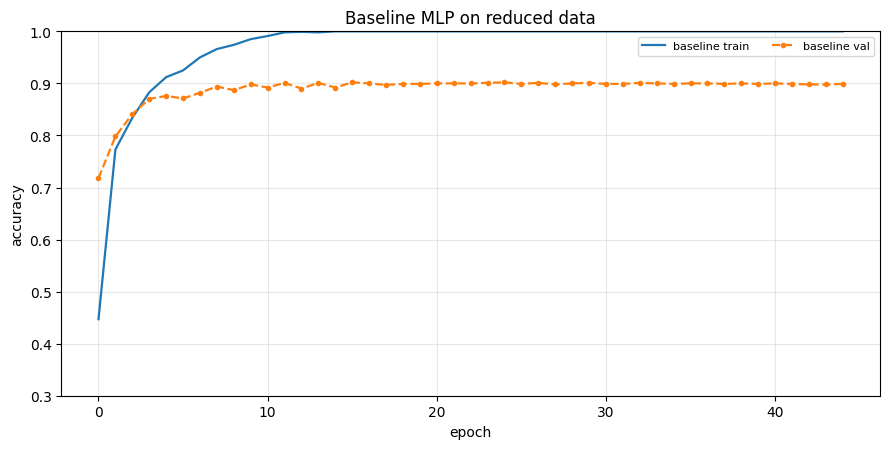

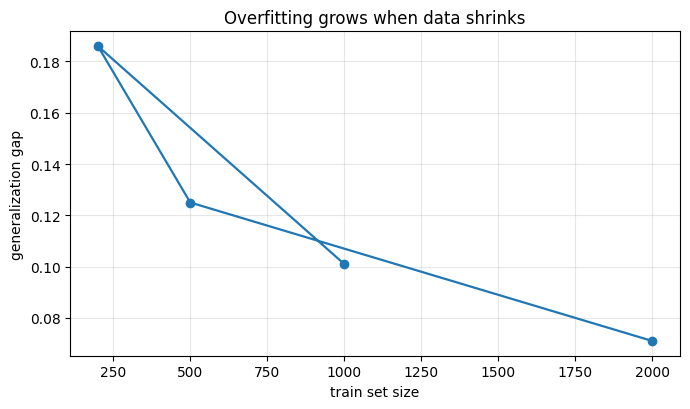

In [4]:
# TODO: Phase 2 - define the MLP class and write your own training/plotting code:
#   class MLP(hidden1=256, hidden2=128, num_classes=10):  (structure above, no reg.)
#   def evaluate(model, loader) -> (accuracy, mean_loss)
#   def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, seed=SEED)
#       -> history dict with lists "train_acc" and "val_acc"
#   def plot_curves(histories, labels, title=None)
# TODO: build a disjoint stratified split (1000 train / 1000 val) + DataLoaders
#       (train_loader, val_loader, test_loader); keep a list: experiments = []
# TODO: train the baseline -> hist_baseline; experiments.append(("baseline", ...))
# TODO: plot its train/val curves; print the gap table
# TODO: also train with 200 / 500 / 2000 samples and plot gap vs data size

class MLP(nn.Module):
    def __init__(self, hidden1=256, hidden2=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden1),
            nn.ReLU(inplace=True),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(inplace=True),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def make_class_indices(dataset):
    """Map each class id to the list of sample indices of that class."""
    idx_by_class = {}
    for i, (_, y) in enumerate(dataset):
        idx_by_class.setdefault(y, []).append(i)
    return idx_by_class


def sample_per_class(pool, per_class, seed=SEED):
    """Deterministically pick 'per_class' indices from every class."""
    rng = random.Random(seed)
    picked = []
    for y in sorted(pool):
        picked.extend(rng.sample(pool[y], per_class))
    return picked


def make_splits(dataset, train_per_class, val_per_class, seed=SEED):
    """Disjoint (train, val) stratified index pools; train pool is returned."""
    idx_by_class = make_class_indices(dataset)
    rng = random.Random(seed)
    val_idx, pool = [], {}
    for y in sorted(idx_by_class):
        chosen = set(rng.sample(idx_by_class[y], val_per_class))
        val_idx.extend(chosen)
        pool[y] = [i for i in idx_by_class[y] if i not in chosen]
    return pool, val_idx


def evaluate(model, loader):
    """Return (accuracy, mean_loss) of the model on the given loader."""
    model.eval()
    correct = total = 0
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            running_loss += criterion(out, y).item() * x.size(0)
            correct += (out.argmax(dim=1) == y).sum().item()
            total += y.size(0)
    return correct / total, running_loss / total


def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR,
                seed=SEED, verbose=True):
    """Train 'model' (Adam + CrossEntropy); return the history dict."""
    set_seed(seed)
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_acc": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        model.train()
        correct = total = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            correct += (out.argmax(dim=1) == y).sum().item()
            total += y.size(0)
        train_acc = correct / total
        val_acc, _ = evaluate(model, val_loader)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        if verbose:
            print(f"epoch {epoch:2d}/{epochs} | "
                  f"train acc {train_acc:.4f} | val acc {val_acc:.4f}")
    return history


def plot_curves(histories, labels, title=None, y_lim=(0.3, 1.0)):
    """Plot train/val accuracy curves for several histories."""
    fig, ax = plt.subplots(figsize=(9, 4.6))
    for h, lab in zip(histories, labels):
        ax.plot(h["train_acc"], linestyle="-", linewidth=1.6,
                label=lab + " train")
        ax.plot(h["val_acc"], linestyle="--", marker=".", linewidth=1.6,
                label=lab + " val")
    ax.set_xlabel("epoch")
    ax.set_ylabel("accuracy")
    ax.set_ylim(*y_lim)
    ax.grid(alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


pool, val_idx = make_splits(train_full, TRAIN_PER_CLASS, VAL_PER_CLASS)
train_idx = sample_per_class(pool, TRAIN_PER_CLASS, seed=SEED)
train_set = Subset(train_full, train_idx)
val_set = Subset(train_full, val_idx)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)
print(f"train samples: {len(train_idx)} | val samples: {len(val_idx)}")

experiments = []
model_baseline = MLP().to(DEVICE)
hist_baseline = train_model(model_baseline, train_loader, val_loader)
experiments.append(("baseline", hist_baseline))
plot_curves([hist_baseline], ["baseline"], title="Baseline MLP on reduced data")

sizes, gaps = [], []
for per_class in [20, 50, 200]:
    size = 10 * per_class
    idx = sample_per_class(pool, per_class, seed=SEED)
    loader = DataLoader(Subset(train_full, idx), batch_size=BATCH_SIZE,
                        shuffle=True)
    model = MLP().to(DEVICE)
    hist = train_model(model, loader, val_loader, verbose=False)
    experiments.append((f"size={size}", hist))
    sizes.append(size)
    gaps.append(hist["train_acc"][-1] - hist["val_acc"][-1])
sizes.insert(0, len(train_idx))
gaps.insert(0, hist_baseline["train_acc"][-1] - hist_baseline["val_acc"][-1])
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(sizes, gaps, "o-", linewidth=1.6)
ax.set_xlabel("train set size")
ax.set_ylabel("generalization gap")
ax.grid(alpha=0.3)
ax.set_title("Overfitting grows when data shrinks")
plt.tight_layout()
plt.show()


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;">
<li style="text-align: right;">به نمودار دقت نگاه کنید: شکاف بین دقت آموزش و اعتبارسنجی چقدر است؟ این یعنی چه؟</li>
<li style="text-align: right;">نمودار «اندازه داده در برابر شکاف تعمیم» چه روندی دارد؟ چرا؟</li>
<li style="text-align: right;">اگر فقط به دقت آموزش نگاه می‌کردیم چه تصمیم اشتباهی می‌گرفتیم؟</li>
</ul>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;">
<b>پاسخ:</b> مدل پایه با ۱۰۰۰ نمونه بعد از ۴۵ دوره به دقت آموزش ~۱٫۰۰ و دقت اعتبارسنجی ~۰٫۹۰ می‌رسد؛ یعنی شکاف ≈ ۰٫۱۰. این یعنی مدل تقریباً همه نمونه‌های آموزش را «حفظ» کرده ولی روی داده‌های ندیده فقط ۹۰٪ درست کار می‌کند — دقیقاً همان بیش‌برازش.
</p>
<p style="text-align: right;">
روند نمودار نزولی است: با ۲۰۰ نمونه شکاف به ~۰٫۱۹ می‌رسد، با ۵۰۰ ~۰٫۱۳، با ۱۰۰۰ ~۰٫۱۰ و با ۲۰۰۰ به ~۰٫۰۷ می‌رسد. دلیلش ساده است: هرچه داده کمتر باشد، مدل راحت‌تر نمونه‌های محدود را از حفظ می‌کند و کم‌تر ناچار به یادگیری الگوی عمومی می‌شود. (توجه: در همه این اجراها دقت آموزش ~۱ است؛ فقط شکاف عوض می‌شود.)
</p>
<p style="text-align: right;">
اگر فقط دقت آموزش را ببینیم، همه مدل‌ها «عالی» به نظر می‌رسند (~۱٫۰۰) و اصلاً نمی‌فهمیم کدام بهتر است؛ حتی ممکن است بدترین مدل (با ۲۰۰ نمونه) را بهترین انتخاب کنیم. مقایسه باید همیشه روی داده‌ای انجام شود که مدل در آموزش ندیده است.
</p>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۳ — Dropout</h2>
<p style="text-align: right;">
ایده Dropout ساده است: در هر گام آموزش، هر نورون با احتمال <code dir="ltr">p</code> به‌صورت تصادفی خاموش (صفر) می‌شود؛ پس شبکه نمی‌تواند به وابستگی‌های خاص بین نورون‌ها (Co-adaptation) تکیه کند و مجبور می‌شود مسیرهای مقاوم‌تری یاد بگیرد. در زمان ارزیابی، همه نورون‌ها فعال‌اند و خروجی‌ها در طول آموزش با ضریب
</p>
$$
\tilde{x} = \frac{1}{1-p}\, (m \odot x), \qquad m_i \sim \mathrm{Bernoulli}(1-p) \quad (\text{training})
$$
<p style="text-align: right;">
مقیاس می‌شوند تا امید ریاضی خروجی با زمان ارزیابی یکسان بماند (به این نسخه Inverted Dropout می‌گویند، همان کاری که <code dir="ltr">nn.Dropout</code> انجام می‌دهد).
</p>
<p style="text-align: right;">
کلاس <code dir="ltr">DropoutMLP(p=0.5, hidden1=256, hidden2=128, num_classes=10)</code> را با همان ساختار <code dir="ltr">MLP</code> تعریف کنید و یک لایه <code dir="ltr">nn.Dropout(p=p)</code> بعد از <b>هر</b> لایه ReLU اضافه کنید. سپس:
</p>
<ul style="text-align: right;">
<li style="text-align: right;">با <code dir="ltr">p=0.5</code> روی همان <code dir="ltr">train_loader</code> (۱۰۰۰ نمونه) آموزش دهید → <code dir="ltr">hist_dropout</code>؛ به <code dir="ltr">experiments</code> اضافه کنید و نمودارش را با baseline مقایسه کنید.</li>
<li style="text-align: right;">برای <code dir="ltr">p</code> ∈ {0.3, 0.5, 0.7} سه بار دیگر با همین پروتکل آموزش دهید (هر بار <code dir="ltr">set_seed(SEED)</code>) و همه را با هم رسم کنید تا اثر مقدار p را ببینید.</li>
</ul>
</div>


epoch  1/45 | train acc 0.2280 | val acc 0.5990
epoch  2/45 | train acc 0.4900 | val acc 0.7630
epoch  3/45 | train acc 0.6160 | val acc 0.8090
epoch  4/45 | train acc 0.6780 | val acc 0.8440
epoch  5/45 | train acc 0.7320 | val acc 0.8440
epoch  6/45 | train acc 0.8100 | val acc 0.8670
epoch  7/45 | train acc 0.8040 | val acc 0.8730
epoch  8/45 | train acc 0.8510 | val acc 0.8810
epoch  9/45 | train acc 0.8670 | val acc 0.8790
epoch 10/45 | train acc 0.8830 | val acc 0.8800
epoch 11/45 | train acc 0.8870 | val acc 0.8860
epoch 12/45 | train acc 0.8850 | val acc 0.8880
epoch 13/45 | train acc 0.9060 | val acc 0.8940
epoch 14/45 | train acc 0.9100 | val acc 0.8890
epoch 15/45 | train acc 0.9340 | val acc 0.8920
epoch 16/45 | train acc 0.9370 | val acc 0.8980
epoch 17/45 | train acc 0.9320 | val acc 0.9000
epoch 18/45 | train acc 0.9400 | val acc 0.8990
epoch 19/45 | train acc 0.9640 | val acc 0.9010
epoch 20/45 | train acc 0.9480 | val acc 0.9040
epoch 21/45 | train acc 0.9430 | val acc

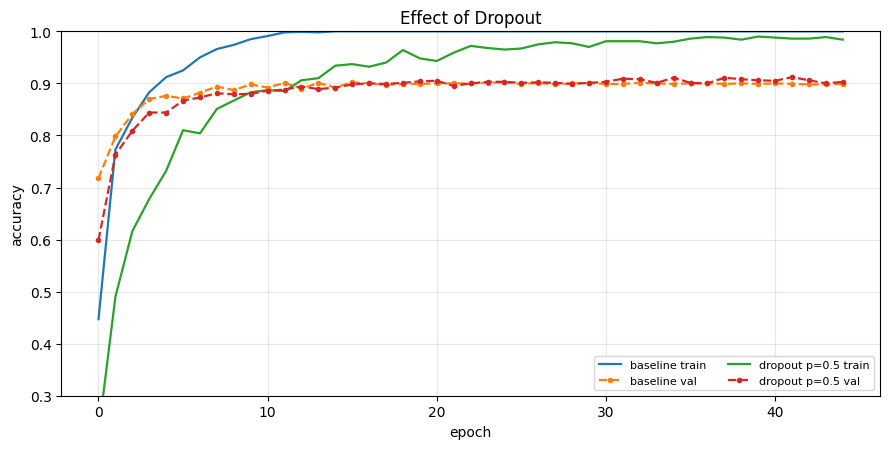

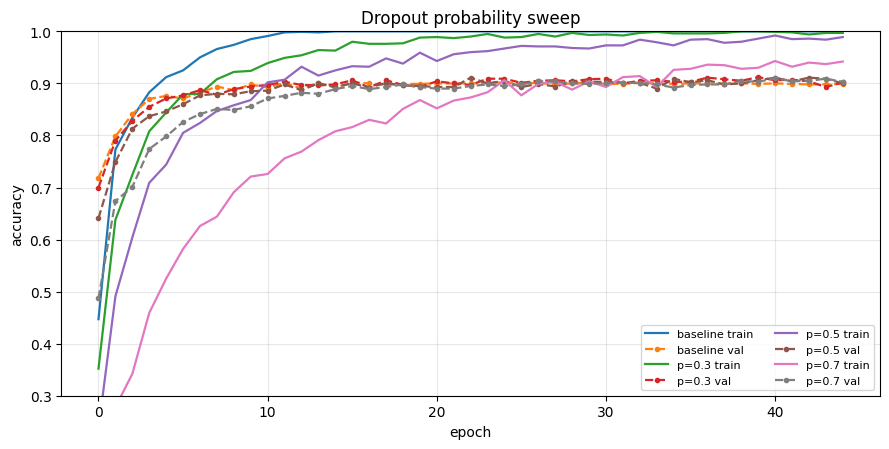

In [5]:
# TODO: Phase 3 - define DropoutMLP(p=0.5) (MLP + nn.Dropout after every ReLU)
# TODO: train it on the same train_loader -> hist_dropout; add it to experiments
# TODO: plot baseline vs dropout curves
# TODO: sweep p in [0.3, 0.5, 0.7] with the same protocol and plot all together

class DropoutMLP(nn.Module):
    def __init__(self, p=0.5, hidden1=256, hidden2=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden1),
            nn.ReLU(inplace=True),
            nn.Dropout(p=p),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(inplace=True),
            nn.Dropout(p=p),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


model_dropout = DropoutMLP(p=0.5).to(DEVICE)
hist_dropout = train_model(model_dropout, train_loader, val_loader)
experiments.append(("dropout (p=0.5)", hist_dropout))
plot_curves([hist_baseline, hist_dropout], ["baseline", "dropout p=0.5"],
            title="Effect of Dropout")

hist_p = {}
for p in [0.3, 0.5, 0.7]:
    model = DropoutMLP(p=p).to(DEVICE)
    hist_p[p] = train_model(model, train_loader, val_loader, verbose=False)
    experiments.append((f"dropout p={p}", hist_p[p]))
plot_curves([hist_baseline, hist_p[0.3], hist_p[0.5], hist_p[0.7]],
            ["baseline", "p=0.3", "p=0.5", "p=0.7"],
            title="Dropout probability sweep")


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;">
<li style="text-align: right;">Dropout روی دقت آموزش و روی دقت اعتبارسنجی چه اثری گذاشت؟ چرا؟</li>
<li style="text-align: right;">چرا در زمان ارزیابی (evaluate) خبری از خاموش‌کردن نورون‌ها نیست؟ از کجا مطمئن هستیم که <code dir="ltr">nn.Dropout</code> خودش این کار را می‌کند؟</li>
<li style="text-align: right;">در sweep، کدام مقدار p بهتر بود؟ اگر p خیلی بزرگ باشد (مثلاً 0.9) چه اتفاقی می‌افتد؟</li>
</ul>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;">
<b>پاسخ:</b> Dropout دقت آموزش را پایین می‌آورد (از ~۱٫۰۰ به ~۰٫۹۸) ولی دقت اعتبارسنجی را کمی بهتر نگه می‌دارد و شکاف را کوچک می‌کند (از ~۰٫۱۰ به ~۰٫۰۸). دلیلش همان است که گفتیم: مدل نمی‌تواند به نورون‌های مشخصی تکیه کند، پس مجبور می‌شود ویژگی‌ها را به‌صورت توزیع‌شده و مقاوم یاد بگیرد.
</p>
<p style="text-align: right;">
در زمان ارزیابی از کل شبکه (همه نورون‌ها) استفاده می‌کنیم. <code dir="ltr">nn.Dropout</code> فقط در حالت <code dir="ltr">training=True</code> فعال است (حالتی که <code dir="ltr">model.train()</code> روشن می‌کند) و در حالت <code dir="ltr">model.eval()</code> به‌صورت خودکار بی‌اثر می‌شود. برای اینکه امید ریاضی خروجی بین دو حالت یکسان بماند، خروجی‌ها در زمان آموزش در <code dir="ltr">1/(1-p)</code> ضرب می‌شوند.
</p>
<p style="text-align: right;">
در sweep ما بهترین دقت اعتبارسنجی در <code dir="ltr">p=0.5</code> به دست آمد (~۰٫۹۰). با <code dir="ltr">p=0.7</code> اختلال خیلی شدید می‌شود: مدل وقت کافی برای یادگیری پیدا نمی‌کند و دقت آموزش هم بالا نمی‌رود (کم‌آموزشی = Underfitting). پس p یک dial است: کم‌تر از حد، اثری ندارد؛ زیاد از حد، یادگیری را خفه می‌کند.
</p>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۴ — Batch Normalization: از صفر و با PyTorch</h2>
<h3 style="text-align: right;">توضیح Batch Normalization</h3>
<p style="text-align: right;">
در طول آموزش، وزن‌های لایه‌ها مدام تغییر می‌کنند و در نتیجه توزیع ورودی هر لایه هم مدام عوض می‌شود؛ این «تغییر توزیع داخلی» (Internal Covariate Shift) آموزش را ناپایدار و کند می‌کند.
Batch Normalization در هر مینی‌بچ، فعال‌سازی‌های هر کانال/ویژگی را با میانگین و واریانس همان مینی‌بچ نرمال می‌کند و سپس با دو پارامتر قابل یادگیری <code dir="ltr">γ</code> (مقیاس) و <code dir="ltr">β</code> (جابه‌جایی) باز مقیاس می‌کند:
</p>
$$
\mu_{\mathcal{B}} = \frac{1}{m}\sum_{i=1}^{m} x_i, \qquad
\sigma_{\mathcal{B}}^2 = \frac{1}{m}\sum_{i=1}^{m} (x_i - \mu_{\mathcal{B}})^2
$$
$$
\hat{x}_i = \frac{x_i - \mu_{\mathcal{B}}}{\sqrt{\sigma_{\mathcal{B}}^2 + \epsilon}}, \qquad
y_i = \gamma \hat{x}_i + \beta
$$
<p style="text-align: right;">
دو نکته مهم:
</p>
<ul style="text-align: right;">
<li style="text-align: right;"><b>حالت آموزش در برابر ارزیابی:</b> در زمان آموزش از آمار همان مینی‌بچ استفاده می‌کنیم و میانگین/واریانس «جاری» (running) را هم با momentum به‌روز می‌کنیم؛ در زمان ارزیابی از همین آمار جاری استفاده می‌شود، چون یک مینی‌بچ تنها، نماینده خوبی از توزیع نیست. (همه این‌ها با <code dir="ltr">model.train()</code> و <code dir="ltr">model.eval()</code> کنترل می‌شود.)</li>
<li style="text-align: right;"><b>چرا منظم‌سازی ملایم؟</b> چون هر نمونه در طول آموزش «با کمی نویز» (نویز حاصل از آمار مینی‌بچ‌های متفاوت) دیده می‌شود؛ این نویز مثل یک Regularizer ضعیف عمل می‌کند. اثر اصلی BN اما پایدار و سریع‌کردن آموزش است.</li>
</ul>
<h3 style="text-align: right;">پیاده‌سازی از صفر</h3>
<p style="text-align: right;">
کلاس <code dir="ltr">BatchNorm1dScratch(num_features, eps=1e-5, momentum=0.1)</code> را بسازید — همان کاری که <code dir="ltr">nn.BatchNorm1d</code> می‌کند. قراردادها:
</p>
<ul style="text-align: right;">
<li style="text-align: right;">پارامترهای قابل یادگیری: <code dir="ltr">gamma</code> (یک‌های اولیه) و <code dir="ltr">beta</code> (صفرهای اولیه) از جنس <code dir="ltr">nn.Parameter</code>.</li>
<li style="text-align: right;">بافرهای (بدون گرادیان) <code dir="ltr">running_mean</code> (صفر اولیه) و <code dir="ltr">running_var</code> (یک اولیه) با <code dir="ltr">register_buffer</code> تا وقتی مدل جابه‌جا می‌شود همراه‌اش بروند.</li>
<li style="text-align: right;">در حالت آموزش: میانگین و واریانس <b>مربع‌خطای همان مینی‌بچ</b> (<code dir="ltr">x.var(dim=0, unbiased=False)</code>); آمار جاری را با momentum به‌روز کنید (داخل <code dir="ltr">torch.no_grad()</code>): <code dir="ltr">running = (1-momentum) * running + momentum * batch</code>.</li>
<li style="text-align: right;">در حالت ارزیابی (<code dir="ltr">self.training=False</code>): با آمار جاری نرمال کنید. در هر دو حالت: <code dir="ltr">y = gamma * x_hat + beta</code>.</li>
</ul>
<p style="text-align: right;">
سپس دو مدل بسازید: <code dir="ltr">BNMLP(hidden1=256, hidden2=128, num_classes=10)</code> که از <code dir="ltr">BatchNorm1dScratch</code> استفاده می‌کند و <code dir="ltr">BNMLPTorch</code> که فقط همین لایه‌ها را با <code dir="ltr">nn.BatchNorm1d</code> عوض کرده (ساختار هر دو: <code dir="ltr">Linear → BN → ReLU</code> برای هر لایه پنهان). هر دو را روی همان ۱۰۰۰ نمونه آموزش دهید → <code dir="ltr">hist_scratch</code> و <code dir="ltr">hist_torch</code>؛ به <code dir="ltr">experiments</code> اضافه کنید و هر سه منحنی (baseline، scratch، torch) را با هم رسم کنید.
</p>
</div>


epoch  1/45 | train acc 0.5790 | val acc 0.7270
epoch  2/45 | train acc 0.8840 | val acc 0.8540
epoch  3/45 | train acc 0.9270 | val acc 0.8840
epoch  4/45 | train acc 0.9560 | val acc 0.8940
epoch  5/45 | train acc 0.9760 | val acc 0.8980
epoch  6/45 | train acc 0.9900 | val acc 0.8990
epoch  7/45 | train acc 0.9970 | val acc 0.9010
epoch  8/45 | train acc 1.0000 | val acc 0.9080
epoch  9/45 | train acc 1.0000 | val acc 0.9070
epoch 10/45 | train acc 1.0000 | val acc 0.9150
epoch 11/45 | train acc 1.0000 | val acc 0.9110
epoch 12/45 | train acc 1.0000 | val acc 0.9110
epoch 13/45 | train acc 1.0000 | val acc 0.9130
epoch 14/45 | train acc 1.0000 | val acc 0.9110
epoch 15/45 | train acc 1.0000 | val acc 0.9120
epoch 16/45 | train acc 1.0000 | val acc 0.9130
epoch 17/45 | train acc 1.0000 | val acc 0.9080
epoch 18/45 | train acc 1.0000 | val acc 0.9110
epoch 19/45 | train acc 1.0000 | val acc 0.9150
epoch 20/45 | train acc 1.0000 | val acc 0.9180
epoch 21/45 | train acc 1.0000 | val acc

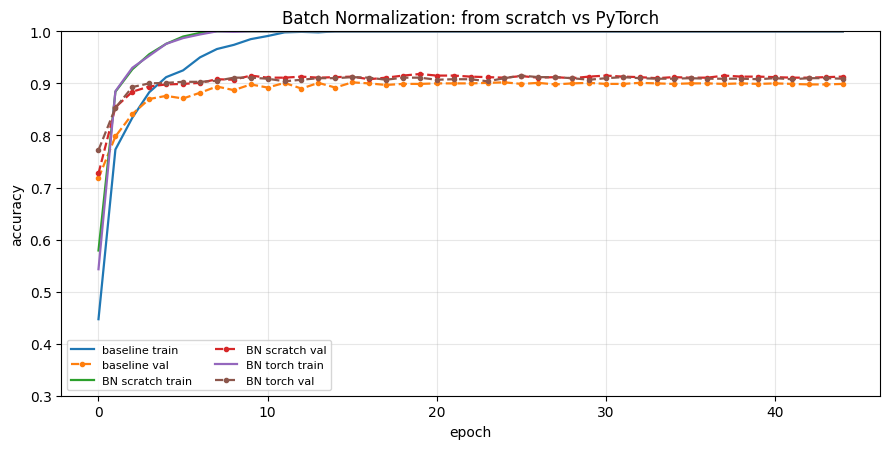

In [6]:
# TODO: Phase 4 - implement BatchNorm1dScratch(num_features, eps=1e-5, momentum=0.1)
#   (gamma/beta parameters; running_mean/running_var buffers; batch stats while
#    training + running-stat update; running stats while evaluating)
# TODO: define BNMLP (uses BatchNorm1dScratch) and BNMLPTorch (uses nn.BatchNorm1d)
#       structure per hidden layer: Linear -> BN -> ReLU
# TODO: train both on the same train_loader -> hist_scratch, hist_torch
# TODO: add them to experiments and plot baseline vs scratch vs torch

class BatchNorm1dScratch(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))
        self.register_buffer("running_mean", torch.zeros(num_features))
        self.register_buffer("running_var", torch.ones(num_features))

    def forward(self, x):
        if self.training:
            batch_mean = x.mean(dim=0)
            batch_var = x.var(dim=0, unbiased=False)
            with torch.no_grad():
                self.running_mean.mul_(1 - self.momentum) \
                    .add_(self.momentum * batch_mean)
                self.running_var.mul_(1 - self.momentum) \
                    .add_(self.momentum * batch_var)
            x_hat = (x - batch_mean) / torch.sqrt(batch_var + self.eps)
        else:
            x_hat = (x - self.running_mean) / torch.sqrt(self.running_var + self.eps)
        return self.gamma * x_hat + self.beta


class BNMLP(nn.Module):
    """MLP with our from-scratch BatchNorm after every hidden linear layer."""
    def __init__(self, hidden1=256, hidden2=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden1),
            BatchNorm1dScratch(hidden1),
            nn.ReLU(inplace=True),
            nn.Linear(hidden1, hidden2),
            BatchNorm1dScratch(hidden2),
            nn.ReLU(inplace=True),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class BNMLPTorch(nn.Module):
    """Same MLP but with PyTorch's nn.BatchNorm1d (one-line change)."""
    def __init__(self, hidden1=256, hidden2=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(inplace=True),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(inplace=True),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


model_scratch = BNMLP().to(DEVICE)
hist_scratch = train_model(model_scratch, train_loader, val_loader)
experiments.append(("batchnorm (scratch)", hist_scratch))

model_torch = BNMLPTorch().to(DEVICE)
hist_torch = train_model(model_torch, train_loader, val_loader)
experiments.append(("batchnorm (torch)", hist_torch))
hist_batchnorm = hist_scratch

plot_curves([hist_baseline, hist_scratch, hist_torch],
            ["baseline", "BN scratch", "BN torch"],
            title="Batch Normalization: from scratch vs PyTorch")


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;">
<li style="text-align: right;">آیا دو پیاده‌سازی (از صفر و nn.BatchNorm1d) نتایج نزدیکی گرفتند؟ چه چیزی را باید با هم مقایسه کرد؟</li>
<li style="text-align: right;">Batch Normalization روی سرعت همگرایی چه اثری گذاشت؟ دقت اعتبارسنجی چطور؟</li>
<li style="text-align: right;">چرا در زمان ارزیابی از آمار جاری (running) استفاده می‌کنیم نه آمار مینی‌بچ؟</li>
</ul>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;">
<b>پاسخ:</b> بله، دو پیاده‌سازی نتایج تقریباً یکسانی می‌دهند (در اجرای مرجع: دقت اعتبارسنجی ~۰٫۹۱ برای هر دو) — چون هر دو دقیقاً همان ریاضی را اجرا می‌کنند (همان eps و momentum و همان آمار). مقایسه درست، مقایسه روی <b>همان داده، همان seed و همان تعداد دوره</b> است، نه فقط در نگاه‌کردن به یک عدد.
</p>
<p style="text-align: right;">
BN سرعت همگرایی را به‌وضوح بالا می‌برد: دقت آموزش خیلی زودتر به ~۱ می‌رسد و دقت اعتبارسنجی هم در همین تعداد دوره از ~۰٫۹۰ به ~۰٫۹۱ بهتر می‌شود؛ چون ورودی هر لایه نرمال می‌ماند و گرادیان‌ها پایدارترند. اثر منظم‌سازی ملایم آن هم کمک کوچکی می‌کند.
</p>
<p style="text-align: right;">
در زمان ارزیابی، یک مینی‌بچ (مثلاً ۱۲۸ نمونه) ترکیب تصادفی کوچکی است و میانگین/واریانسش از نمونه‌ای به نمونه دیگر می‌لرزد و به ترتیب داده هم وابسته است. آمار جاری، میانگین متحرکی از «همه» مینی‌بچ‌های آموزش است و تخمین پایدارتری از توزیع واقعی فعال‌سازی‌ها می‌دهد.
</p>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۵ — Data Augmentation (آماده + سفارشی)</h2>
<p style="text-align: right;">
Augmentation راهی برای «جبران کمبود داده» است: به‌جای تغییری در مدل، تغییراتی تصادفی و بی‌ضرر روی خود داده اعمال می‌کنیم، طوری که برچسب داده عوض نشود:
</p>
$$
\tilde{x} = f(x), \qquad f \in \mathcal{F} \;\; (\text{جابه‌جایی، چرخش، کوچک‌نمایی و …})
$$
<p style="text-align: right;">
هر دوره آموزش، مدل داده‌ها را «تازه» می‌بیند و نمی‌تواند نمونه‌های خاص را حفظ کند. برای ارقام دست‌نویس، وارونه‌کردن یا چرخش‌های بزرگ معنی ندارد، ولی جابه‌جایی و چرخش‌های کوچک کاملاً بی‌ضرر است.
</p>
<h3 style="text-align: right;">۱) تبدیل‌های آماده</h3>
<p style="text-align: right;">
تبدیل <code dir="ltr">aug_train_transform</code> را بسازید:
</p>
<ul style="text-align: right;">
<li style="text-align: right;"><code dir="ltr">T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1))</code> — چرخش تا ۱۰ درجه، جابه‌جایی تا ۱۰٪ و تغییر اندازه.</li>
<li style="text-align: right;">سپس <code dir="ltr">ToTensor</code> و <code dir="ltr">Normalize</code> مثل قبل.</li>
</ul>
<p style="text-align: right;">
یک مجموعه آموزشِ <b>همان‌داده</b> (همان <code dir="ltr">train_idx</code>) ولی با این تبدیل بسازید → <code dir="ltr">aug_train_loader</code>؛ چند نمونه تقویت‌شده را نمایش دهید؛ سپس <b>همان <code dir="ltr">MLP</code></b> (بدون Dropout و BN — تا اثر Augmentation خالص دیده شود) را با آن آموزش دهید → <code dir="ltr">hist_augment</code> و با baseline مقایسه کنید.
</p>
<h3 style="text-align: right;">۲) یک augmentation سفارشی بسازید</h3>
<p style="text-align: right;">
در PyTorch هر «تبدیل» فقط یک کلاس با متد <code dir="ltr">__call__</code> است (و معمولاً <code dir="ltr">__repr__</code>) تا داخل <code dir="ltr">T.Compose</code> قرار بگیرد. کلاس <code dir="ltr">RandomShift(max_shift=2)</code> را پیاده‌سازی کنید که رقم را به‌اندازه تصادفی (حداکثر <code dir="ltr">max_shift</code> پیکسل) جابه‌جا می‌کند:
</p>
<ul style="text-align: right;">
<li style="text-align: right;">دو عدد تصادفی <code dir="ltr">dx, dy</code> از بازه <code dir="ltr">[-max_shift, max_shift]</code> با <code dir="ltr">random.randint</code>.</li>
<li style="text-align: right;">اعمال با تابع آماده <code dir="ltr">TF.affine(img, angle=0, translate=(dx, dy), scale=1.0, shear=0.0)</code>.</li>
</ul>
<p style="text-align: right;">
سپس ترکیبی از «چرخش/جابه‌جایی آماده + RandomShift سفارشی» بسازید → <code dir="ltr">custom_loader</code>؛ چند نمونه آن را نمایش دهید؛ با آن آموزش دهید → <code dir="ltr">hist_custom</code> و با تبدیل آماده مقایسه کنید. به این نکته توجه کنید که Augmentation فقط روی داده آموزش اعمال می‌شود، نه روی اعتبارسنجی یا آزمون.
</p>
</div>


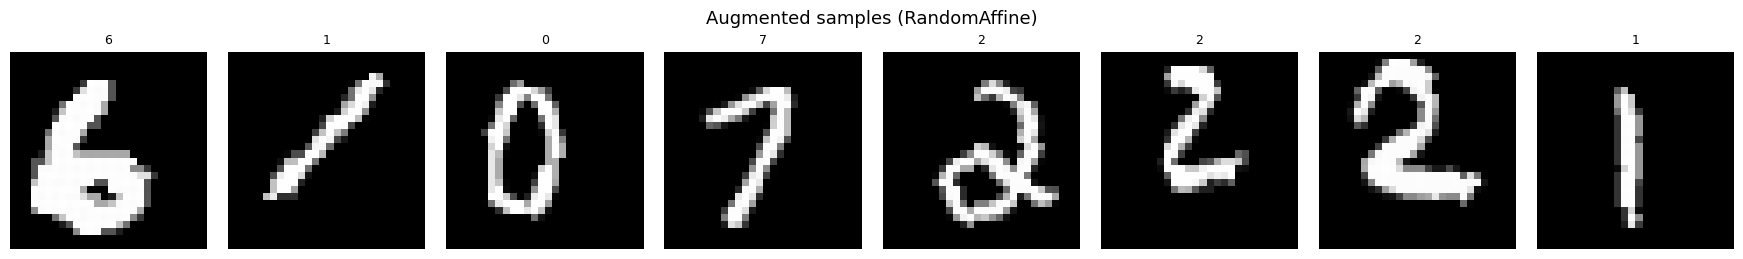

epoch  1/45 | train acc 0.2730 | val acc 0.6420
epoch  2/45 | train acc 0.4840 | val acc 0.7210
epoch  3/45 | train acc 0.5380 | val acc 0.7560
epoch  4/45 | train acc 0.5760 | val acc 0.8160
epoch  5/45 | train acc 0.6470 | val acc 0.8070
epoch  6/45 | train acc 0.6630 | val acc 0.8320
epoch  7/45 | train acc 0.6780 | val acc 0.8110
epoch  8/45 | train acc 0.6690 | val acc 0.8620
epoch  9/45 | train acc 0.7150 | val acc 0.8700
epoch 10/45 | train acc 0.7320 | val acc 0.8710
epoch 11/45 | train acc 0.7420 | val acc 0.8860
epoch 12/45 | train acc 0.7580 | val acc 0.8800
epoch 13/45 | train acc 0.7810 | val acc 0.8670
epoch 14/45 | train acc 0.7910 | val acc 0.9070
epoch 15/45 | train acc 0.8100 | val acc 0.9010
epoch 16/45 | train acc 0.8320 | val acc 0.9020
epoch 17/45 | train acc 0.8350 | val acc 0.9100
epoch 18/45 | train acc 0.8440 | val acc 0.9150
epoch 19/45 | train acc 0.8410 | val acc 0.9240
epoch 20/45 | train acc 0.8740 | val acc 0.9120
epoch 21/45 | train acc 0.8770 | val acc

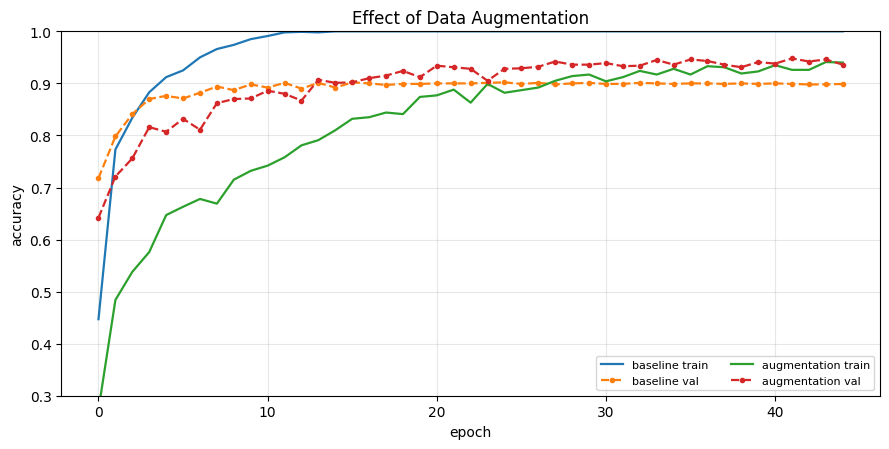

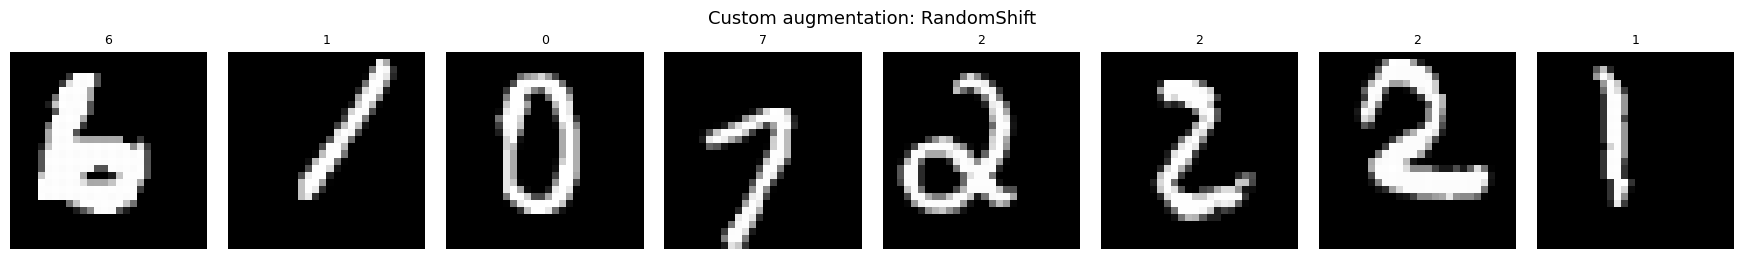

epoch  1/45 | train acc 0.2640 | val acc 0.6310
epoch  2/45 | train acc 0.4410 | val acc 0.7260
epoch  3/45 | train acc 0.5210 | val acc 0.7280
epoch  4/45 | train acc 0.5540 | val acc 0.7860
epoch  5/45 | train acc 0.6030 | val acc 0.7800
epoch  6/45 | train acc 0.6510 | val acc 0.8250
epoch  7/45 | train acc 0.6980 | val acc 0.8260
epoch  8/45 | train acc 0.7010 | val acc 0.8550
epoch  9/45 | train acc 0.7210 | val acc 0.8510
epoch 10/45 | train acc 0.7540 | val acc 0.8570
epoch 11/45 | train acc 0.7730 | val acc 0.8740
epoch 12/45 | train acc 0.8000 | val acc 0.8860
epoch 13/45 | train acc 0.8200 | val acc 0.8870
epoch 14/45 | train acc 0.8190 | val acc 0.8780
epoch 15/45 | train acc 0.8110 | val acc 0.8910
epoch 16/45 | train acc 0.8370 | val acc 0.8930
epoch 17/45 | train acc 0.8420 | val acc 0.9060
epoch 18/45 | train acc 0.8570 | val acc 0.9200
epoch 19/45 | train acc 0.8580 | val acc 0.9180
epoch 20/45 | train acc 0.8540 | val acc 0.9050
epoch 21/45 | train acc 0.8870 | val acc

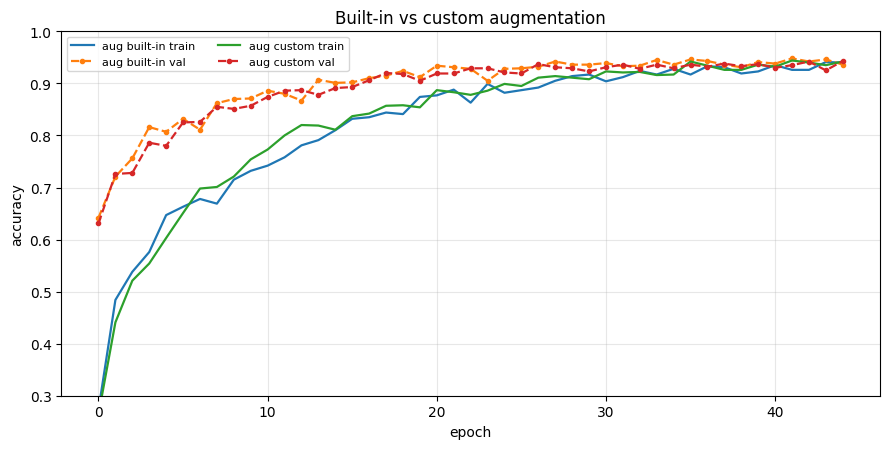

In [7]:
# TODO: Phase 5 - build the augmentation transform (RandomAffine + ToTensor + Normalize)
#       on the same train_idx -> aug_train_loader; show 8 augmented samples
# TODO: train the plain MLP with it -> hist_augment; add to experiments; plot vs baseline
# TODO: write the custom class RandomShift(max_shift=2)  (__call__ via TF.affine + __repr__)
# TODO: custom_transform = RandomAffine(degrees=5, translate=(0.08, 0.08)) + RandomShift(2)
#       + ToTensor + Normalize  -> custom_loader; show 8 samples; train -> hist_custom;
#       add to experiments; plot built-in vs custom

def show_grid(dataset, n=8, title=None):
    """Plot n random samples of a dataset in a row."""
    rng = random.Random(SEED)
    ids = rng.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.6))
    for ax, i in zip(axes, ids):
        img, y = dataset[i]
        img = np.clip(img.squeeze(0).numpy() * MNIST_STD + MNIST_MEAN, 0.0, 1.0)
        ax.imshow(img, cmap="gray")
        ax.set_title(str(y), fontsize=9)
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


aug_train_transform = T.Compose([
    T.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    T.ToTensor(),
    T.Normalize(MNIST_MEAN, MNIST_STD),
])
aug_train_set = Subset(MNIST(root=DATA_ROOT, train=True, download=True,
                             transform=aug_train_transform), train_idx)
aug_train_loader = DataLoader(aug_train_set, batch_size=BATCH_SIZE, shuffle=True)
show_grid(aug_train_set, title="Augmented samples (RandomAffine)")

model_augment = MLP().to(DEVICE)
hist_augment = train_model(model_augment, aug_train_loader, val_loader)
experiments.append(("augmentation", hist_augment))
plot_curves([hist_baseline, hist_augment], ["baseline", "augmentation"],
            title="Effect of Data Augmentation")


class RandomShift:
    """Custom augmentation: shift the digit by a random number of pixels."""
    def __init__(self, max_shift=2):
        self.max_shift = max_shift

    def __call__(self, img):
        dx = random.randint(-self.max_shift, self.max_shift)
        dy = random.randint(-self.max_shift, self.max_shift)
        return TF.affine(img, angle=0, translate=(dx, dy), scale=1.0, shear=0.0)

    def __repr__(self):
        return f"RandomShift(max_shift={self.max_shift})"


custom_transform = T.Compose([
    T.RandomAffine(degrees=5, translate=(0.08, 0.08)),
    RandomShift(max_shift=2),
    T.ToTensor(),
    T.Normalize(MNIST_MEAN, MNIST_STD),
])
custom_set = Subset(MNIST(root=DATA_ROOT, train=True, download=True,
                          transform=custom_transform), train_idx)
custom_loader = DataLoader(custom_set, batch_size=BATCH_SIZE, shuffle=True)
show_grid(custom_set, title="Custom augmentation: RandomShift")

model_custom = MLP().to(DEVICE)
hist_custom = train_model(model_custom, custom_loader, val_loader)
experiments.append(("augmentation (custom)", hist_custom))
plot_curves([hist_augment, hist_custom], ["aug built-in", "aug custom"],
            title="Built-in vs custom augmentation")


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;">
<li style="text-align: right;">چرا Augmentation را فقط روی داده آموزش اعمال می‌کنیم و نه روی اعتبارسنجی/آزمون؟</li>
<li style="text-align: right;">کدام تبدیل‌ها برای ارقام دست‌نویس «بی‌ضرر»اند و کدام‌ها ممکن است برچسب را عوض کنند؟ (مثلاً ۶↔۹ یا ۷↔۱ را در نظر بگیرید.)</li>
<li style="text-align: right;">تفاوت کلاس سفارشی <code dir="ltr">RandomShift</code> با تبدیل‌های آماده torchvision چیست؟ قابلیت Compose چه چیزی را ممکن می‌کند؟</li>
</ul>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;">
<b>پاسخ:</b> اعتبارسنجی و آزمون باید نماینده «داده واقعی در دنیای واقعی» باشند؛ اگر آن‌ها را هم دستکاری کنیم، دقتی که می‌سنجیم دیگر دقت روی داده واقعی نیست و مقایسه مدل‌ها گمراه‌کننده می‌شود. هدف Augmentation این است که مدل «انواع بیشتری از داده واقعی» را هنگام آموزش ببیند، نه اینکه معیار ارزیابی را تغییر دهیم.
</p>
<p style="text-align: right;">
جابه‌جایی و چرخش کوچک و تغییر اندازه جزئی برای ارقام بی‌ضررند (یک «۲» جابه‌جا شده همچنان «۲» است). اما وارون‌کردن افقی، «۶» را شبیه «۹» می‌کند، چرخش ۱۸۰ درجه دوباره ۶↔۹ یا ۷↔۱ را عوض می‌کند، و چرخش‌های بزرگ (مثلاً ۹۰ درجه) بسیاری از برچسب‌ها را نامفهوم می‌کند — این‌ها تبدیل‌هایی هستند که برچسب را تغییر می‌دهند و نباید استفاده شوند. انتخاب دامنه تبدیل‌ها (degrees پایین، translate کم) دقیقاً برای همین است.
</p>
<p style="text-align: right;">
تبدیل‌های آماده torchvision فقط کلاس‌های آماده‌ای هستند که <code dir="ltr">__call__</code> (و <code dir="ltr">__repr__</code>) دارند. کلاس سفارشی ما دقیقاً همان قرارداد را دنبال می‌کند، پس تفاوت فنی‌ای وجود ندارد — تفاوت در این است که خودمان منطقش را نوشتیم و هر تبدیل دلخواهی (نویز، حذف تصادفی، اعوجاج و …) را می‌توان به همین سادگی ساخت. <code dir="ltr">T.Compose</code> هم فقط این کلاس‌ها را به ترتیب روی تصویر صدا می‌زند؛ پس هر کلاسی که این قرارداد را داشته باشد داخل Compose کار می‌کند.
</p>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ۶ — ترکیب همه: Dropout + Batch Normalization + Augmentation</h2>
<p style="text-align: right;">
هر سه ابزار مکانیزم‌های متفاوتی دارند و انتظار داریم ترکیبشان بهتر از تک‌تک آن‌ها باشد:
</p>
<ul style="text-align: right;">
<li style="text-align: right;">Augmentation — داده متنوع‌تر و «غنی‌تر» می‌سازد.</li>
<li style="text-align: right;">Dropout — وابستگی به نورون‌های خاص را می‌شکند.</li>
<li style="text-align: right;">Batch Normalization — آموزش را پایدار و سریع می‌کند.</li>
</ul>
<p style="text-align: right;">
کلاس <code dir="ltr">RegularizedMLP(p=0.3, hidden1=256, hidden2=128, num_classes=10)</code> را تعریف کنید: همان ساختار <code dir="ltr">MLP</code> + <code dir="ltr">BatchNorm1d</code> (بعد از هر <code dir="ltr">Linear</code> پنهان) + <code dir="ltr">Dropout(p)</code> (بعد از هر ReLU). مدل نهایی را با همان ۱۰۰۰ نمونه اما با داده تقویت‌شده — ترکیبی که <code dir="ltr">RandomShift</code> سفارشی دارد یعنی <code dir="ltr">custom_loader</code> — آموزش دهید → <code dir="ltr">final_model</code> و <code dir="ltr">hist_final</code>؛ به <code dir="ltr">experiments</code> اضافه کنید. سپس همه آزمایش‌ها را در یک نمودار و در جدول نهایی (یک حلقه چاپ) کنار هم ببینید. این متغیرها در فاز ارزیابی استفاده می‌شوند.
</p>
</div>


epoch  1/45 | train acc 0.2400 | val acc 0.6360
epoch  2/45 | train acc 0.4590 | val acc 0.7490
epoch  3/45 | train acc 0.5340 | val acc 0.7800
epoch  4/45 | train acc 0.5800 | val acc 0.7990
epoch  5/45 | train acc 0.6140 | val acc 0.8170
epoch  6/45 | train acc 0.6570 | val acc 0.8390
epoch  7/45 | train acc 0.6790 | val acc 0.8460
epoch  8/45 | train acc 0.6860 | val acc 0.8570
epoch  9/45 | train acc 0.7270 | val acc 0.8520
epoch 10/45 | train acc 0.7230 | val acc 0.8590
epoch 11/45 | train acc 0.7350 | val acc 0.8720
epoch 12/45 | train acc 0.7620 | val acc 0.8790
epoch 13/45 | train acc 0.7600 | val acc 0.8920
epoch 14/45 | train acc 0.7680 | val acc 0.8970
epoch 15/45 | train acc 0.7800 | val acc 0.9050
epoch 16/45 | train acc 0.7610 | val acc 0.9140
epoch 17/45 | train acc 0.7960 | val acc 0.9100
epoch 18/45 | train acc 0.8070 | val acc 0.9020
epoch 19/45 | train acc 0.8150 | val acc 0.9040
epoch 20/45 | train acc 0.7930 | val acc 0.9200
epoch 21/45 | train acc 0.8110 | val acc

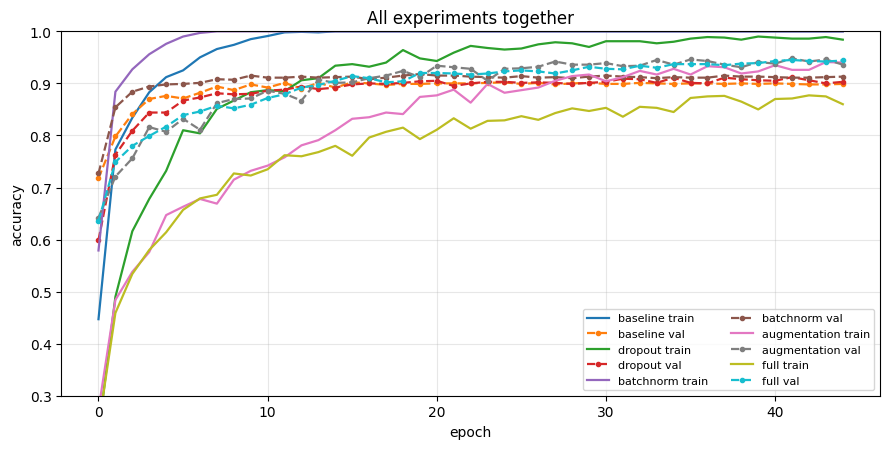

experiment               train acc   val acc       gap
------------------------------------------------------
baseline                    1.0000    0.8990    0.1010
size=200                    1.0000    0.8140    0.1860
size=500                    1.0000    0.8750    0.1250
size=2000                   1.0000    0.9290    0.0710
dropout (p=0.5)             0.9840    0.9030    0.0810
dropout p=0.3               0.9970    0.9020    0.0950
dropout p=0.5               0.9890    0.9000    0.0890
dropout p=0.7               0.9420    0.9030    0.0390
batchnorm (scratch)         1.0000    0.9130    0.0870
batchnorm (torch)           1.0000    0.9090    0.0910
augmentation                0.9400    0.9360    0.0040
augmentation (custom)       0.9420    0.9430   -0.0010
full (bn+dropout+aug)       0.8600    0.9440   -0.0840


In [8]:
# TODO: Phase 6 - define RegularizedMLP(p=0.3): MLP + BatchNorm1d after every
#       hidden Linear + Dropout(p) after every ReLU
# TODO: train it on custom_loader -> final_model, hist_final; add to experiments
# TODO: plot all experiments together and print the summary gap table

class RegularizedMLP(nn.Module):
    def __init__(self, p=0.3, hidden1=256, hidden2=128, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(inplace=True),
            nn.Dropout(p=p),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(inplace=True),
            nn.Dropout(p=p),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)


final_model = RegularizedMLP(p=0.3).to(DEVICE)
hist_final = train_model(final_model, custom_loader, val_loader)
experiments.append(("full (bn+dropout+aug)", hist_final))
plot_curves([hist_baseline, hist_dropout, hist_batchnorm, hist_augment, hist_final],
            ["baseline", "dropout", "batchnorm", "augmentation", "full"],
            title="All experiments together")

print(f"{'experiment':<24}{'train acc':>10}{'val acc':>10}{'gap':>10}")
print("-" * 54)
for name, h in experiments:
    tr, va = h["train_acc"][-1], h["val_acc"][-1]
    print(f"{name:<24}{tr:>10.4f}{va:>10.4f}{tr - va:>10.4f}")


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="text-align: right;">بحث کنید</h3>
<ul style="text-align: right;">
<li style="text-align: right;">کدام تکنیک بیشترین کاهش شکاف تعمیم را داشت؟ چرا فکر می‌کنید؟</li>
<li style="text-align: right;">چرا ترکیب سه تکنیک بهتر از تک‌تک آن‌هاست؟ آیا این سه همدیگر را «بی‌اثر» هم می‌کنند؟</li>
<li style="text-align: right;">آیا دقت اعتبارسنجیِ مدل کامل می‌تواند تخمین درستی از دقت دنیای واقعی باشد؟ چه آزمایش دیگری پیشنهاد می‌دهید؟</li>
</ul>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;">
<b>پاسخ:</b> در اجرای مرجع، Augmentation بیشترین اثر را داشت (دقت اعتبارسنجی از ~۰٫۹۰ به ~۰٫۹۴)؛ چون مستقیماً به «منبع» بیش‌برازش حمله می‌کند — کمبود داده — و با هر دوره، نمونه‌های تازه‌ای می‌سازد. Dropout و Batch Normalization هم مؤثر بودند ولی اثرشان کمتر بود (هرکدام چند دهم درصد بهتر از baseline). این ترتیب اثر به مسئله بستگی دارد و در مسئله‌ای دیگر ممکن است فرق کند — همین، دلیل مهمی برای آزمایش‌کردن است.
</p>
<p style="text-align: right;">
این سه مکانیزم به جنبه‌های متفاوتی حمله می‌کنند: Augmentation داده را غنی‌تر می‌کند، Dropout وابستگی نورون‌ها را می‌شکند و BN مسیر بهینه‌سازی را پایدار می‌کند. چون «حلقه‌های ضعف» متفاوت‌اند، اثرشان تقریباً جمع می‌شود و همدیگر را خنثی نمی‌کنند — در نتیجه مدل کامل (~۰٫۹۴ اعتبارسنجی و آزمون) بهتر از هر تکنیک به تنهایی است. نکته جالب: دقت آموزش مدل کامل از دقت اعتبارسنجی پایین‌تر است (شکاف منفی)؛ یعنی Regularization آن‌قدر قوی است که مدل حتی «حفظ‌کردن» داده محدود را هم کامل یاد نمی‌گیرد — و این دقیقاً کاری است که می‌خواستیم.
</p>
<p style="text-align: right;">
دقت اعتبارسنجی تخمین خوبی است ولی کامل نیست: به حجم اعتبارسنجی، نویز اجرا و شانس تقسیم داده وابسته است. برای اطمینان بیشتر می‌توان چند بار با seedهای مختلف اجرا کرد و میانگین/انحراف را گزارش داد، از Cross-Validation استفاده کرد، یا مدل را روی داده متنوع‌تر (مثلاً EMNIST) آزمود.
</p>
</div>


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">فاز ارزیابی — نتیجه کار خودتان را ببینید</h2>
<p style="text-align: right;">
سلول زیر نتیجه نهایی کار شما را محاسبه و نمایش می‌دهد: جدول کامل آزمایش‌ها (دقت نهایی آموزش، دقت اعتبارسنجی و شکاف تعمیم هر مدل — از لیست <code dir="ltr">experiments</code>) و دقت مدل نهایی روی <b>مجموعه آزمون</b> (۱۰٬۰۰۰ تصویری که مدل هیچ‌وقت آن‌ها را ندیده).
</p>
<p style="text-align: right;">
<b>نکته:</b> این سلول به متغیرهای <code dir="ltr">experiments</code>، <code dir="ltr">final_model</code>، <code dir="ltr">evaluate</code> و <code dir="ltr">test_loader</code> نیاز دارد؛ اگر هنوز همه سلول‌های فازهای قبل را اجرا نکرده‌اید، اول آن‌ها را به‌ترتیب اجرا کنید.
</p>
<p style="text-align: right;">
مقدار مورد انتظار راه‌حل مرجع: دقت آزمون مدل کامل <b dir="ltr">≈ 0.94</b> — در حالی که مدل پایه (بدون Regularization) روی همین داده حدود ۰٫۹۰ می‌گیرد و شانس (حدس تصادفی) ۰٫۱ است. شکاف تعمیم مدل پایه ≈ 0.10 و مدل کامل ≈ -0.08 است (اعداد دقیق به سخت‌افزار و نسخه کتابخانه‌ها کمی وابسته‌اند).
</p>
<p style="text-align: right;color: var(--jp-ui-font-color2, #6b7280);">
خروجی سلول مرجع زیر (که اجرا نمی‌کنید) مقدار راه‌حل طراح را نشان می‌دهد — نتیجه خودتان را با آن مقایسه کنید.
</p>
</div>


In [9]:
# Evaluation cell - run it and compare with the reference value
print("device:", DEVICE)
print(f"{'experiment':<24}{'train acc':>10}{'val acc':>10}{'gap':>10}")
print("-" * 54)
for name, h in experiments:
    tr, va = h["train_acc"][-1], h["val_acc"][-1]
    print(f"{name:<24}{tr:>10.4f}{va:>10.4f}{tr - va:>10.4f}")
test_acc, _ = evaluate(final_model, test_loader)
print(f"\nfinal model test accuracy: {test_acc:.4f}")
print(f"random guessing baseline: {1.0 / 10:.4f}")


device: cpu
experiment               train acc   val acc       gap
------------------------------------------------------
baseline                    1.0000    0.8990    0.1010
size=200                    1.0000    0.8140    0.1860
size=500                    1.0000    0.8750    0.1250
size=2000                   1.0000    0.9290    0.0710
dropout (p=0.5)             0.9840    0.9030    0.0810
dropout p=0.3               0.9970    0.9020    0.0950
dropout p=0.5               0.9890    0.9000    0.0890
dropout p=0.7               0.9420    0.9030    0.0390
batchnorm (scratch)         1.0000    0.9130    0.0870
batchnorm (torch)           1.0000    0.9090    0.0910
augmentation                0.9400    0.9360    0.0040
augmentation (custom)       0.9420    0.9430   -0.0010
full (bn+dropout+aug)       0.8600    0.9440   -0.0840

final model test accuracy: 0.9405
random guessing baseline: 0.1000


In [10]:
# Reference cell - do NOT run it (kept for comparison only)
# Designer: output of the reference solution after a full execution.
# (your numbers may differ slightly: CPU, library versions)


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right;color: #3498db;">اختیاری — گسترش‌ها</h2>
<p style="text-align: right;">
اگر وقت اضافه دارید، این ایده‌ها را امتحان کنید (هر کدام یک سؤال پژوهشی کوچک است):
</p>
<ul style="text-align: right;">
<li style="text-align: right;"><b>داده کمتر، بیش‌برازش بیشتر:</b> <code dir="ltr">TRAIN_PER_CLASS</code> را در سلول Setup به ۵۰ برسانید و همه مدل‌ها را دوباره مقایسه کنید (یا به ۵۰۰ برسانید و ببینید شکاف تقریباً از بین می‌رود).</li>
<li style="text-align: right;"><b>Weight Decay (L2):</b> در تابع <code dir="ltr">train_model</code> پارامتر <code dir="ltr">weight_decay=1e-4</code> را به <code dir="ltr">Adam</code> اضافه کنید و اثرش را با Dropout مقایسه کنید.</li>
<li style="text-align: right;"><b>Augmentation قوی‌تر:</b> یک کلاس سفارشی دیگر مثلاً <code dir="ltr">AddGaussianNoise</code> بنویسید (اختلال گاوسی روی تنسور بعد از ToTensor) و به ترکیب اضافه کنید.</li>
<li style="text-align: right;"><b>دوره‌های بیشتر:</b> <code dir="ltr">EPOCHS</code> را به ۶۰ برسانید و ببینید کدام مدل‌ها «دیرتر» بیش‌برازش می‌کنند.</li>
<li style="text-align: right;"><b>جای BN:</b> BN را قبل از ReLU و بعد از ReLU مقایسه کنید — آیا فرقی می‌کند؟</li>
</ul>
</div>


In [11]:
# TODO: optional explorations (weight decay, smaller data, custom noise augmentation)


In [12]:
end_time = time.time()
elapsed = end_time - start_time
print(f"Total runtime: {elapsed:.2f} seconds")

Total runtime: 422.85 seconds
